Conductor types:
  1 - Solid round
  2 - Stranded, 7 strands
  3 - Stranded, 19 strands
  4 - Stranded, 37 strands
  5 - ACSR 26/7


Select the type of conductor (1-5):  3
Enter sub-conductor radius r (in meters):  0.04



Number of sub-conductors per bundle:
  2 - Two sub-conductor bundle
  3 - Three sub-conductor bundle
  4 - Four sub-conductor bundle


Select the number of sub-conductors per bundle (2-4):  3
Enter bundle spacing d between adjacent sub-conductors (in meters):  0.5
Enter distance between phase 1 and 2 on the crossarm (in meters):  1.5
Enter distance between phase 2 and 3 on the crossarm (in meters):  1.5



--- Transmission Line Parameters ---
Conductor type = Stranded, 19 strands
Sub-conductors per bundle = 3
Sub-conductor GMR = 0.030320 m
Bundle spacing = 0.500000 m
Bundle GMR = 0.196437 m
Equivalent bundle radius = 0.215443 m
D13 = 3.000000 m
GMD = 1.889882 m
Inductance per phase = 4.527856e-07 H/m
Capacitance per phase = 2.561801e-11 F/m


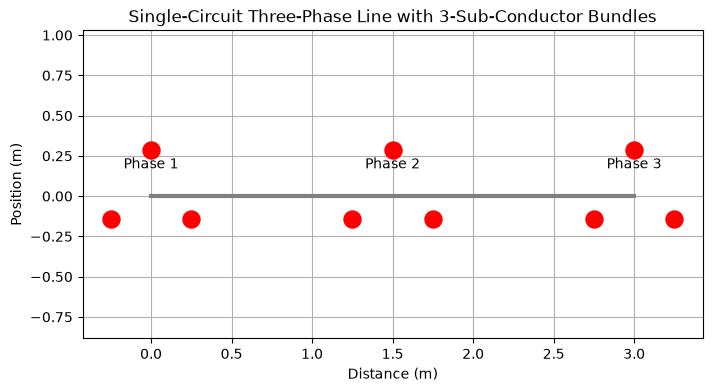

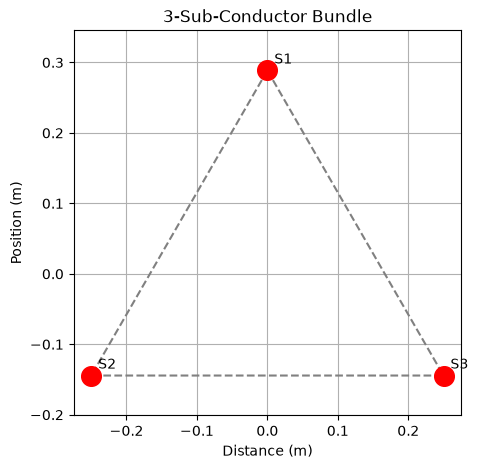

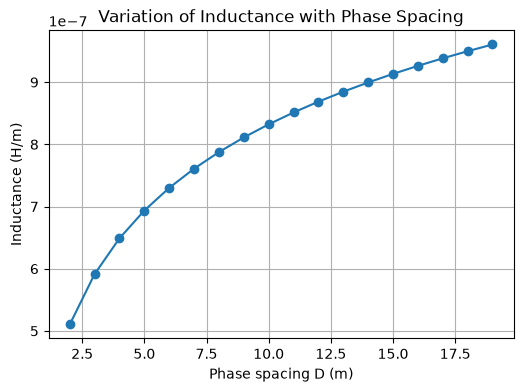

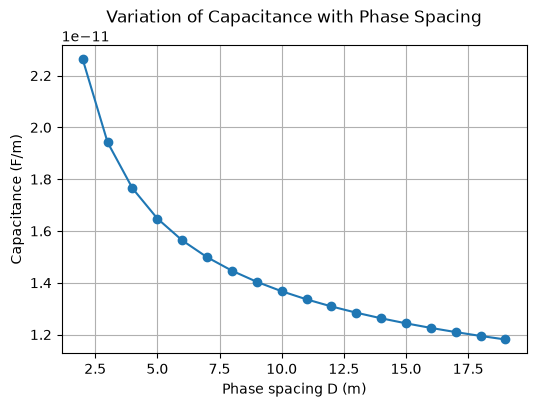

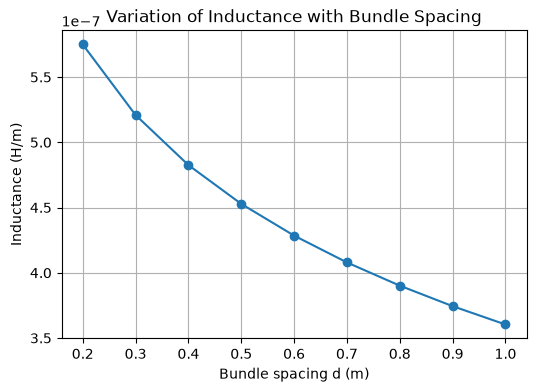

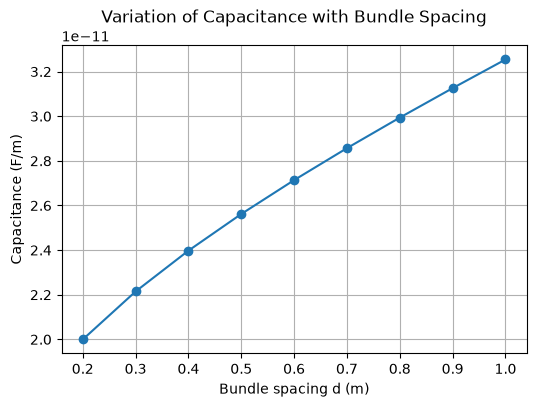


--- Effect of Number of Sub-Conductors ---
 Sub-conductors per bundle  Bundle GMR (m)  Equivalent Radius (m)  Inductance (H/m)  Capacitance (F/m)
                         2        0.123126               0.141421      5.462123e-07       2.145835e-11
                         3        0.196437               0.215443      4.527856e-07       2.561801e-11
                         4        0.270576               0.289982      3.887436e-07       2.967874e-11


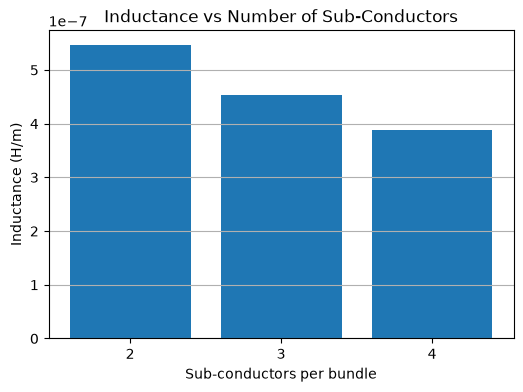

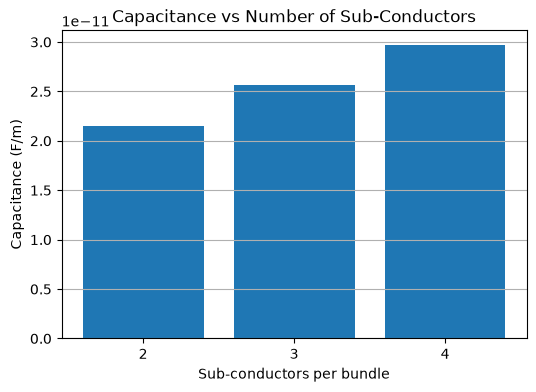


--- Conclusion ---
The inductance increases as phase spacing increases because GMD increases.
The capacitance decreases as phase spacing increases because the electric coupling between the phases decreases.
Bundling increases the effective GMR of the phase conductor, which reduces the inductance of the transmission line.
Bundling increases the equivalent radius used for capacitance, which increases the capacitance of the transmission line.
Increasing the number of sub-conductors in a bundle generally reduces inductance and increases capacitance.
Increasing the spacing between sub-conductors in a bundle also increases the effective GMR and equivalent radius.


In [7]:
# ============================================================
# CALCULATION OF GMR, GMD, INDUCTANCE AND CAPACITANCE
# FOR A SINGLE-CIRCUIT THREE-PHASE TRANSMISSION LINE
# WITH BUNDLED CONDUCTORS
# ============================================================


# Import libraries
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# ============================================================
# STEP 1: INPUT CONDUCTOR DATA
# ============================================================

# Types of conductor and their GMR factors:
#
# GMR = factor * physical radius
#
# These are standard approximate values.

conductor_types = {
    "1": ("Solid round", 0.7788),
    "2": ("Stranded, 7 strands", 0.726),
    "3": ("Stranded, 19 strands", 0.758),
    "4": ("Stranded, 37 strands", 0.768),
    "5": ("ACSR 26/7", 0.81),
}

print("Conductor types:")

for key, value in conductor_types.items():
    print(f"  {key} - {value[0]}")


# Ask until a valid option is chosen

choice = input("Select the type of conductor (1-5): ")

while choice not in conductor_types:
    choice = input(
        "Invalid choice. Select the type of conductor (1-5): "
    )

conductor_name, factor = conductor_types[choice]


# Enter physical radius of ONE sub-conductor

r = float(input(
    "Enter sub-conductor radius r (in meters): "
))


# Calculate GMR of one sub-conductor

GMR = factor * r


# ============================================================
# STEP 2: INPUT BUNDLE DATA
# ============================================================

# Select the number of sub-conductors in each bundle.
#
# The user can choose:
# 2 sub-conductors
# 3 sub-conductors
# 4 sub-conductors

print("\nNumber of sub-conductors per bundle:")
print("  2 - Two sub-conductor bundle")
print("  3 - Three sub-conductor bundle")
print("  4 - Four sub-conductor bundle")


N = input(
    "Select the number of sub-conductors per bundle (2-4): "
)

while N not in ["2", "3", "4"]:
    N = input(
        "Invalid choice. Select the number of sub-conductors "
        "per bundle (2-4): "
    )

N = int(N)


# Enter the spacing between adjacent sub-conductors

d = float(input(
    "Enter bundle spacing d between adjacent sub-conductors "
    "(in meters): "
))


# ============================================================
# STEP 3: CALCULATE BUNDLE GMR AND EQUIVALENT RADIUS
# ============================================================

# Position of the sub-conductors depends on the number
# of sub-conductors in the bundle.
#
# 2 conductors -> horizontal pair
# 3 conductors -> equilateral triangle
# 4 conductors -> square


def bundle_positions(n, spacing):

    # Radius from bundle centre to each sub-conductor

    R = spacing / (2 * math.sin(math.pi / n))


    # Starting angle for a convenient orientation

    start_angles = {
        2: 0,
        3: 90,
        4: 45
    }

    start_angle = math.radians(start_angles[n])


    angles = [
        start_angle + (2 * math.pi * k / n)
        for k in range(n)
    ]


    x = [
        R * math.cos(angle)
        for angle in angles
    ]

    y = [
        R * math.sin(angle)
        for angle in angles
    ]


    return x, y


# Calculate bundle GMR and equivalent radius

def bundle_values(n, spacing):

    bx, by = bundle_positions(n, spacing)


    # Start with the GMR and physical radius
    # of one sub-conductor

    product_gmr = GMR
    product_radius = r


    # Multiply by distances from the first
    # sub-conductor to the remaining sub-conductors

    for j in range(1, n):

        distance = math.hypot(
            bx[0] - bx[j],
            by[0] - by[j]
        )

        product_gmr *= distance
        product_radius *= distance


    # Equivalent bundle GMR

    GMR_bundle = product_gmr ** (1 / n)


    # Equivalent bundle radius for capacitance

    r_bundle = product_radius ** (1 / n)


    return GMR_bundle, r_bundle


# Calculate bundle values

GMR_bundle, r_bundle = bundle_values(N, d)


# ============================================================
# STEP 4: INPUT PHYSICAL DIMENSIONS OF THE LINE
# ============================================================

# There is one bundle for each phase.
#
# The three phase bundles are arranged horizontally
# on the crossarm.


# Distance between Phase 1 and Phase 2

D12 = float(input(
    "Enter distance between phase 1 and 2 on the crossarm "
    "(in meters): "
))


# Distance between Phase 2 and Phase 3

D23 = float(input(
    "Enter distance between phase 2 and 3 on the crossarm "
    "(in meters): "
))


# Distance between the two outer phases

D13 = D12 + D23


# ============================================================
# STEP 5: CALCULATE GEOMETRIC MEAN DISTANCE (GMD)
# ============================================================

# For a three-phase transmission line:
#
# GMD = (D12 * D23 * D13)^(1/3)


GMD = (D12 * D23 * D13) ** (1 / 3)


# ============================================================
# STEP 6: CALCULATE INDUCTANCE AND CAPACITANCE
# ============================================================

# Inductance per phase per metre:
#
# L = 2e-7 * ln(GMD / GMR_bundle)
#
# Unit: H/m


L = 2e-7 * math.log(
    GMD / GMR_bundle
)


# Permittivity of free space

epsilon_0 = 8.854e-12


# Capacitance per phase per metre:
#
# C = (2 * pi * epsilon_0) /
#     ln(GMD / r_bundle)
#
# Unit: F/m


C = (
    2 * math.pi * epsilon_0
) / math.log(
    GMD / r_bundle
)


# ============================================================
# STEP 7: DISPLAY RESULTS
# ============================================================

print("\n--- Transmission Line Parameters ---")

print(f"Conductor type = {conductor_name}")

print(f"Sub-conductors per bundle = {N}")

print(f"Sub-conductor GMR = {GMR:.6f} m")

print(f"Bundle spacing = {d:.6f} m")

print(f"Bundle GMR = {GMR_bundle:.6f} m")

print(f"Equivalent bundle radius = {r_bundle:.6f} m")

print(f"D13 = {D13:.6f} m")

print(f"GMD = {GMD:.6f} m")

print(
    f"Inductance per phase = {L:.6e} H/m"
)

print(
    f"Capacitance per phase = {C:.6e} F/m"
)


# ============================================================
# STEP 8: VISUALIZATION OF CONDUCTOR ARRANGEMENT
# ============================================================

# Position of the three bundle centres:
#
# Phase 1 -> x = 0
# Phase 2 -> x = D12
# Phase 3 -> x = D12 + D23


x_centres = [
    0,
    D12,
    D12 + D23
]

y_centres = [
    0,
    0,
    0
]

labels = [
    "Phase 1",
    "Phase 2",
    "Phase 3"
]


# Obtain positions of sub-conductors
# inside one bundle

bx, by = bundle_positions(N, d)


# Create the figure

plt.figure(figsize=(8, 4))


# Draw the crossarm

plt.plot(
    [0, D13],
    [0, 0],
    color="gray",
    linewidth=3
)


# Draw each bundle

for i in range(3):

    for j in range(N):

        plt.scatter(
            x_centres[i] + bx[j],
            y_centres[i] + by[j],
            s=150,
            color="red",
            zorder=3
        )


    # Label each phase

    plt.annotate(
        labels[i],
        (x_centres[i], y_centres[i]),
        xytext=(0, 20),
        textcoords="offset points",
        fontsize=10,
        ha="center"
    )


plt.title(
    f"Single-Circuit Three-Phase Line "
    f"with {N}-Sub-Conductor Bundles"
)

plt.xlabel("Distance (m)")

plt.ylabel("Position (m)")

plt.grid(True)

plt.axis("equal")

plt.show()


# ============================================================
# STEP 9: SHOW ONE BUNDLE IN DETAIL
# ============================================================

plt.figure(figsize=(5, 5))


# Connect the sub-conductors

plt.plot(
    bx + [bx[0]],
    by + [by[0]],
    linestyle="--",
    color="gray"
)


# Plot sub-conductors

plt.scatter(
    bx,
    by,
    s=200,
    color="red",
    zorder=3
)


# Label sub-conductors

for i in range(N):

    plt.annotate(
        f"S{i + 1}",
        (bx[i], by[i]),
        xytext=(5, 5),
        textcoords="offset points"
    )


plt.title(
    f"{N}-Sub-Conductor Bundle"
)

plt.xlabel("Distance (m)")

plt.ylabel("Position (m)")

plt.grid(True)

plt.axis("equal")

plt.show()


# ============================================================
# STEP 10: VARIATION OF INDUCTANCE AND CAPACITANCE
# WITH PHASE SPACING
# ============================================================

# Assume a symmetrical straight-line arrangement:
#
# D12 = D
# D23 = D
# D13 = 2D
#
# Therefore:
#
# GMD = (D * D * 2D)^(1/3)


# Generate phase spacing values from 2 m to 19 m

distances = [
    i for i in range(2, 20)
]


# Lists for calculated values

inductances = []

capacitances = []


# Calculate values for each phase spacing

for D in distances:

    # Calculate GMD

    GMD_var = (
        D * D * (2 * D)
    ) ** (1 / 3)


    # Calculate inductance

    L_var = (
        2e-7 *
        math.log(GMD_var / GMR_bundle)
    )


    # Calculate capacitance

    C_var = (
        2 * math.pi * epsilon_0
    ) / math.log(
        GMD_var / r_bundle
    )


    inductances.append(L_var)

    capacitances.append(C_var)


# ============================================================
# STEP 11: PLOT VARIATION OF INDUCTANCE
# WITH PHASE SPACING
# ============================================================

plt.figure(figsize=(6, 4))

plt.plot(
    distances,
    inductances,
    marker="o"
)

plt.title(
    "Variation of Inductance with Phase Spacing"
)

plt.xlabel(
    "Phase spacing D (m)"
)

plt.ylabel(
    "Inductance (H/m)"
)

plt.grid(True)

plt.show()


# ============================================================
# STEP 12: PLOT VARIATION OF CAPACITANCE
# WITH PHASE SPACING
# ============================================================

plt.figure(figsize=(6, 4))

plt.plot(
    distances,
    capacitances,
    marker="o"
)

plt.title(
    "Variation of Capacitance with Phase Spacing"
)

plt.xlabel(
    "Phase spacing D (m)"
)

plt.ylabel(
    "Capacitance (F/m)"
)

plt.grid(True)

plt.show()


# ============================================================
# STEP 13: VARIATION WITH BUNDLE SPACING
# ============================================================

# Keep the phase spacing fixed.
#
# Vary the distance between sub-conductors
# inside each bundle.


bundle_spacings = np.linspace(
    0.2,
    1.0,
    9
)


bundle_inductances = []

bundle_capacitances = []


for spacing in bundle_spacings:

    # Calculate bundle GMR and equivalent radius

    GMR_var, r_var = bundle_values(
        N,
        spacing
    )


    # Calculate inductance

    L_var = (
        2e-7 *
        math.log(GMD / GMR_var)
    )


    # Calculate capacitance

    C_var = (
        2 * math.pi * epsilon_0
    ) / math.log(
        GMD / r_var
    )


    bundle_inductances.append(L_var)

    bundle_capacitances.append(C_var)


# ============================================================
# STEP 14: PLOT INDUCTANCE VS BUNDLE SPACING
# ============================================================

plt.figure(figsize=(6, 4))

plt.plot(
    bundle_spacings,
    bundle_inductances,
    marker="o"
)

plt.title(
    "Variation of Inductance with Bundle Spacing"
)

plt.xlabel(
    "Bundle spacing d (m)"
)

plt.ylabel(
    "Inductance (H/m)"
)

plt.grid(True)

plt.show()


# ============================================================
# STEP 15: PLOT CAPACITANCE VS BUNDLE SPACING
# ============================================================

plt.figure(figsize=(6, 4))

plt.plot(
    bundle_spacings,
    bundle_capacitances,
    marker="o"
)

plt.title(
    "Variation of Capacitance with Bundle Spacing"
)

plt.xlabel(
    "Bundle spacing d (m)"
)

plt.ylabel(
    "Capacitance (F/m)"
)

plt.grid(True)

plt.show()


# ============================================================
# STEP 16: EFFECT OF NUMBER OF SUB-CONDUCTORS
# ============================================================

# Compare bundles containing:
#
# 2 sub-conductors
# 3 sub-conductors
# 4 sub-conductors
#
# using the same conductor, bundle spacing
# and phase spacing.


numbers = [2, 3, 4]

L_numbers = []

C_numbers = []


for n in numbers:

    # Calculate bundle GMR and equivalent radius

    g_n, r_n = bundle_values(
        n,
        d
    )


    # Calculate inductance

    L_n = (
        2e-7 *
        math.log(GMD / g_n)
    )


    # Calculate capacitance

    C_n = (
        2 * math.pi * epsilon_0
    ) / math.log(
        GMD / r_n
    )


    L_numbers.append(L_n)

    C_numbers.append(C_n)


# Create results table

bundle_table = pd.DataFrame({

    "Sub-conductors per bundle": numbers,

    "Bundle GMR (m)": [
        bundle_values(n, d)[0]
        for n in numbers
    ],

    "Equivalent Radius (m)": [
        bundle_values(n, d)[1]
        for n in numbers
    ],

    "Inductance (H/m)": L_numbers,

    "Capacitance (F/m)": C_numbers

})


print(
    "\n--- Effect of Number of Sub-Conductors ---"
)

print(
    bundle_table.to_string(index=False)
)


# ============================================================
# STEP 17: PLOT EFFECT OF NUMBER OF SUB-CONDUCTORS
# ============================================================

plt.figure(figsize=(6, 4))

plt.bar(
    [str(n) for n in numbers],
    L_numbers
)

plt.title(
    "Inductance vs Number of Sub-Conductors"
)

plt.xlabel(
    "Sub-conductors per bundle"
)

plt.ylabel(
    "Inductance (H/m)"
)

plt.grid(
    True,
    axis="y"
)

plt.show()


plt.figure(figsize=(6, 4))

plt.bar(
    [str(n) for n in numbers],
    C_numbers
)

plt.title(
    "Capacitance vs Number of Sub-Conductors"
)

plt.xlabel(
    "Sub-conductors per bundle"
)

plt.ylabel(
    "Capacitance (F/m)"
)

plt.grid(
    True,
    axis="y"
)

plt.show()


# ============================================================
# STEP 18: CONCLUSION
# ============================================================

print("\n--- Conclusion ---")

print(
    "The inductance increases as phase spacing increases "
    "because GMD increases."
)

print(
    "The capacitance decreases as phase spacing increases "
    "because the electric coupling between the phases decreases."
)

print(
    "Bundling increases the effective GMR of the phase conductor, "
    "which reduces the inductance of the transmission line."
)

print(
    "Bundling increases the equivalent radius used for capacitance, "
    "which increases the capacitance of the transmission line."
)

print(
    "Increasing the number of sub-conductors in a bundle "
    "generally reduces inductance and increases capacitance."
)

print(
    "Increasing the spacing between sub-conductors in a bundle "
    "also increases the effective GMR and equivalent radius."
)